# NIDS — Fixed & Cleaned

Changes vs. original are tagged with `# FIX:` (bug fixes) and `# MOD:` (improvements).

In [102]:
!pip install -q git+https://github.com/Blealtan/efficient-kan.git
!pip install -q polars kagglehub

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 1. Imports & Configuration

In [103]:
import os, gc, random, datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import polars as pl
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score
from efficient_kan import KAN
import pandas as pd
import matplotlib.pyplot as plt
# FIX: removed duplicate `import gc` (was imported twice)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42

def seed_everything(seed: int = SEED):
    """FIX: single, complete seeding routine that can be re-invoked before each
    experiment config, so every (arch, source) run starts from an identical RNG
    state instead of inheriting whatever the previous run consumed."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False        # FIX: was never disabled

seed_everything(SEED)

def seeded_generator(seed: int = SEED) -> torch.Generator:
    """FIX: DataLoader shuffles were driven by the global RNG; give shuffling
    loaders their own seeded generator for run-to-run reproducibility."""
    g = torch.Generator()
    g.manual_seed(seed)
    return g

############################ TO CHANGE ACROSS RUNS #############################
SPLINE_TRUE     = True

# ── Data ──────────────────────────────────────────────────────────────────────
SAMPLE_N        = 1_000_000
################################################################################
BATCH_SIZE      = 256
TTA_BATCH_SIZE  = 512        # larger batches = more stable gradient estimates

# ── Model ─────────────────────────────────────────────────────────────────────
LATENT_DIM      = 32

# ── Pre-training ──────────────────────────────────────────────────────────────
PRETRAIN_EPOCHS = 20
PRETRAIN_LR     = 1e-3
WEIGHT_DECAY    = 1e-4
RECON_W         = 0.5        # reconstruction regularises encoder for transfer

# ── CTTA ──────────────────────────────────────────────────────────────────────
FEW_SHOT_RATIO  = 0.0001     # fraction of target used as labelled pool
FEW_SHOT_MATCH_STEPS = False  # MOD: give the few-shot baseline the SAME number
                             # of optimizer steps as CTTA takes over the stream
                             # (previously 20 epochs = 20 steps vs CTTA's ~196
                             # — a hidden 10x step-budget advantage for CTTA in
                             # one direction and for few-shot in the other,
                             # depending on architecture). With matched steps,
                             # stream access is the ONLY difference.
AGSA_ABLATION   = True       # MOD: for KAN, rerun the headline CTTA mode with
                             # the spline gate OFF (same RNG/weights) and also
                             # record source-set F1 after adaptation — the two
                             # numbers that validate AGSA (no target cost +
                             # forgetting protection).
SCRATCH_BASELINE = True      # MOD: also run few-shot and CTTA from a RANDOM
                             # init (no source pretraining) with the same
                             # objectives and step budget, training ALL
                             # parameters — layer-selective updates on a
                             # random frozen encoder would be meaningless, so
                             # full-capacity training is the strongest honest
                             # form of this baseline. Quantifies the value of
                             # source pretraining.
MIN_POOL_SIZE   = 100        # MOD: hard floor so the pool never collapses
FEW_SHOT_W      = 1.0        # supervised CE weight during CTTA
TTA_LR          = 1e-2       # higher lr is fine — only norm params updated
TTA_STEPS       = 1
USE_ENTROPY     = True       # FIX(v1): term was silently commented out of the
                             # loss. FIX(v2): plain entropy min made CTTA worse
                             # — replaced by a robust variant (see
                             # stream_entropy_loss): confidence-filtered,
                             # confidence-weighted, and prior-anchored.
ENTROPY_W       = 1.0        # weight on the filtered entropy term
ENT_CONF_FRAC   = 0.4        # EATA-style reliability threshold: only samples
                             # with entropy < ENT_CONF_FRAC * ln(2) contribute
MARGINAL_W      = 1.0        # weight on KL(batch-mean prediction || pool
                             # prior) — anti-collapse anchor for imbalance
RECON_W_TTA     = 0.5        # reconstruction weight during CTTA
RECON_SOURCE    = 'stream'   # FIX: 'pool' recon (original) was redundant — it
                             # ran on the same ~100 samples CE already trains
                             # on every step, so it added no signal and no
                             # improvement. 'stream' turns it into TTT-style
                             # self-supervision on the unlabelled stream, where
                             # the shift actually is. Options:
                             #   'stream' | 'pool' | 'both' | 'none'
RESTORE_PROB    = 0.01       # MOD: stochastic restore (CoTTA) — after each
                             # update, each trainable weight snaps back to its
                             # source value with this probability. Bounds
                             # cumulative drift over long streams; the main
                             # defence against unsupervised collapse (the
                             # 'ent-only F1=0.01' failure). 0 disables.

# ── AGSA: Activation-Gated Spline Adaptation (NOVELTY, KAN-only) ──────────────
# KAN spline coefficients are LOCAL: each B-spline basis governs one region of
# an input's range. Coefficients of regions the target stream never visits get
# near-zero (pure-noise) gradients — but Adam's per-parameter normalisation
# amplifies them into full-size updates, silently corrupting the learned
# function exactly where the target provides no evidence. AGSA tracks which
# basis functions target data actually activates (EMA over stream + pool
# forwards) and hard-masks gradients for dormant coefficients: adaptation is
# confined to regions the target exercises, source knowledge elsewhere is
# structurally frozen. Architecture-intrinsic retention — no penalty term, no
# extra loss, no effect on visited-region fitting.
USE_SPLINE_GATE   = True
SPLINE_GATE_EMA   = 0.99     # EMA horizon for basis-activation mass
SPLINE_GATE_THRESH = 0.05    # coefficient is 'active' if its EMA mass exceeds
                             # this fraction of the max mass on that input dim
EWC_LAMBDA      = 0.0        # MOD/FIX: KAN_Retention (EWC) was computed but its
                             # penalty was NEVER added to the CTTA loss. Set > 0
                             # (e.g. 100.0) to actually apply retention.

# ── Loss (MOD: class imbalance) ───────────────────────────────────────────────
# 'ce'          : plain CrossEntropy (original behaviour)
# 'weighted_ce' : CrossEntropy with inverse-frequency class weights, computed
#                 from whatever labelled data trains each phase (source train
#                 split for pretraining, labelled pool for CTTA / few-shot)
# 'focal'       : Focal loss (Lin et al. 2017) with per-class alpha from the
#                 same inverse-frequency weights + focusing parameter gamma
LOSS_TYPE        = 'weighted_ce'
FOCAL_GAMMA      = 2.0
MAX_CLASS_WEIGHT = 20.0      # cap — a 100-sample pool with ~3 attacks would
                             # otherwise produce weights >16 and destabilise
                             # CTTA's already-high learning rate

# ── Scaling (MOD: transfer-friendly scaling) ──────────────────────────────────
# 'minmax'   : MinMaxScaler(-1, 1) + clip                (original behaviour)
# 'robust'   : median/IQR scaling; ±ROBUST_CLIP scaled units map to ±1, clip
# 'quantile' : rank-based QuantileTransformer -> uniform [-1, 1]. Immune to
#              heavy tails, and out-of-distribution target values saturate
#              gracefully at the grid boundary instead of a whole feature
#              collapsing when the source min/max doesn't cover target range
SCALER_TYPE = 'quantile'
ROBUST_CLIP = 4.0            # only used when SCALER_TYPE == 'robust'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'[System] Seed={SEED} | Device={device}')
print(f'[System] Loss={LOSS_TYPE} | Scaler={SCALER_TYPE}')

[System] Seed=42 | Device=cuda
[System] Loss=weighted_ce | Scaler=quantile


## 1b. Scaling & imbalance-aware losses (MOD)

In [104]:
from sklearn.preprocessing import RobustScaler, QuantileTransformer

class FeatureScaler:
    """
    MOD: pluggable scaling strategy behind the same fit/transform interface the
    rest of the pipeline already uses, so it drops in wherever a MinMaxScaler
    was passed around. Every mode guarantees float32 output in [-1, 1], which
    the KAN grid_range=[-1, 1] requires.

    'minmax'   — exactly the original behaviour (MinMax to [-1,1], then clip).
    'robust'   — (x - median) / IQR per feature; ±ROBUST_CLIP scaled units map
                 to ±1 and everything beyond clips. Outliers no longer define
                 the range, so the bulk of the data keeps its resolution.
    'quantile' — rank-based map to uniform [0,1] rescaled to [-1,1]. Fully
                 immune to heavy tails; out-of-range target values saturate at
                 the boundary instead of compressing the whole feature. This is
                 the transfer-friendliest option: when the source scaler is
                 reused on a shifted target, minmax can push a large share of a
                 feature onto the clip boundary, while quantile degrades softly.
    """
    def __init__(self, kind: str = SCALER_TYPE):
        if kind not in ('minmax', 'robust', 'quantile'):
            raise ValueError(f"Unknown SCALER_TYPE={kind!r}. "
                             f"Choose 'minmax', 'robust', or 'quantile'")
        self.kind = kind
        self._sk = None

    def fit(self, X):
        if self.kind == 'minmax':
            self._sk = MinMaxScaler(feature_range=(-1, 1)).fit(X)
        elif self.kind == 'robust':
            self._sk = RobustScaler(quantile_range=(5.0, 95.0)).fit(X)
        else:  # quantile
            self._sk = QuantileTransformer(
                output_distribution='uniform',
                n_quantiles=min(1000, len(X)),   # n_quantiles must be <= n_samples
                subsample=1_000_000,
                random_state=SEED,
            ).fit(X)
        return self

    def transform(self, X):
        if self._sk is None:
            raise RuntimeError('FeatureScaler.transform called before fit')
        Z = self._sk.transform(X)
        if self.kind == 'robust':
            Z = Z / ROBUST_CLIP                  # ±ROBUST_CLIP IQR-units -> ±1
        elif self.kind == 'quantile':
            Z = Z * 2.0 - 1.0                    # [0,1] -> [-1,1]
        return np.clip(Z, -1, 1).astype(np.float32)


def compute_class_weights(y) -> torch.Tensor:
    """
    MOD: inverse-frequency ('balanced') weights, w_c = N / (n_classes * N_c),
    capped at MAX_CLASS_WEIGHT. Accepts a numpy array or a torch tensor.
    Falls back to uniform weights if a class is absent (can happen in a tiny
    pool) so the criterion never divides by zero.
    """
    if isinstance(y, torch.Tensor):
        y = y.cpu().numpy()
    y = np.asarray(y)
    counts = np.bincount(y, minlength=2).astype(np.float64)
    if (counts == 0).any():
        print('   [class weights] WARNING: a class is missing from the labelled '
              'data — falling back to uniform weights.')
        return torch.ones(2, dtype=torch.float32)
    w = len(y) / (2.0 * counts)
    w = np.minimum(w, MAX_CLASS_WEIGHT)
    return torch.tensor(w, dtype=torch.float32)


class FocalLoss(nn.Module):
    """
    MOD: Focal loss (Lin et al., 2017) for class-imbalanced classification.
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    alpha is a per-class weight tensor (here: the same inverse-frequency
    weights as 'weighted_ce'); gamma down-weights easy examples so training
    focuses on the hard minority. Reduces to alpha-weighted CE at gamma=0.
    """
    def __init__(self, alpha: torch.Tensor = None, gamma: float = FOCAL_GAMMA):
        super().__init__()
        self.gamma = gamma
        # registered as a buffer so .to(device) moves it with the module
        self.register_buffer('alpha',
                             alpha if alpha is not None else torch.ones(2))

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        log_pt    = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt        = log_pt.exp()
        alpha_t   = self.alpha.to(logits.device)[targets]
        loss      = -alpha_t * (1.0 - pt) ** self.gamma * log_pt
        return loss.mean()


def make_criterion(y, device) -> nn.Module:
    """
    MOD: build the classification criterion according to LOSS_TYPE, with class
    statistics taken from the labelled data actually used in that phase
    (source train split for pretraining; labelled pool for CTTA and the
    few-shot baseline). Centralised so every training path stays consistent.
    """
    if LOSS_TYPE == 'ce':
        return nn.CrossEntropyLoss()
    weights = compute_class_weights(y).to(device)
    if LOSS_TYPE == 'weighted_ce':
        print(f'   [criterion] weighted CE | weights='
              f'[benign {weights[0]:.2f}, attack {weights[1]:.2f}]')
        return nn.CrossEntropyLoss(weight=weights)
    if LOSS_TYPE == 'focal':
        print(f'   [criterion] focal (gamma={FOCAL_GAMMA}) | alpha='
              f'[benign {weights[0]:.2f}, attack {weights[1]:.2f}]')
        return FocalLoss(alpha=weights, gamma=FOCAL_GAMMA).to(device)
    raise ValueError(f"Unknown LOSS_TYPE={LOSS_TYPE!r}. "
                     f"Choose 'ce', 'weighted_ce', or 'focal'")


def labels_of(loader) -> torch.Tensor:
    """MOD: pull the label tensor back out of a TensorDataset-backed loader so
    criteria can be built from exactly the data a phase trains on."""
    return loader.dataset.tensors[1]


def reset_loader_generator(loader, seed: int = SEED):
    """
    FIX: shuffling DataLoaders carry their own dedicated torch.Generator,
    which torch.get_rng_state()/set_rng_state() do NOT cover — those only
    snapshot the global RNG. Every 'identical RNG' guarantee (dual-mode CTTA,
    few-shot isolation, ablation restore, AGSA on/off) therefore silently
    excluded pool shuffling. Re-seeding the loader's generator at the start of
    each comparable run makes every run see the identical shuffle sequence by
    construction, independent of what ran before it.
    """
    g = getattr(loader, 'generator', None)
    if g is not None:
        g.manual_seed(seed)


def reseed_loader(loader, seed: int = SEED):
    """FIX: shuffling DataLoaders carry a PRIVATE generator whose state
    advances across runs — torch.set_rng_state does NOT reset it. Without this,
    'matched-RNG' comparisons (spline vs full CTTA, AGSA on vs off, baselines)
    silently saw different pool orderings. Called at the start of every
    adaptation routine so each run consumes an identical shuffle sequence."""
    gen = getattr(loader, 'generator', None)
    if gen is not None:
        gen.manual_seed(seed)


def pool_prior(loader, device) -> torch.Tensor:
    """
    MOD: class prior estimated from the labelled pool. Because the pool is a
    stratified sample of the target, its attack rate is an unbiased estimate
    of the stream's — the one piece of distributional knowledge CTTA is
    legitimately allowed to use. Clamped away from 0 so the KL term below is
    always finite.
    """
    y = labels_of(loader).cpu().numpy()
    r = float(np.mean(y))
    prior = torch.tensor([1.0 - r, r], dtype=torch.float32, device=device)
    return prior.clamp_min(1e-3)


def stream_entropy_loss(logits_s, prior):
    """
    FIX: robust replacement for plain entropy minimisation, which degraded
    CTTA. Plain entropy min fails in two documented ways:

      (1) noisy gradients from unreliable samples — high-entropy predictions
          sit near the decision boundary, and pushing them to be confident in
          whatever direction they currently lean amplifies errors
          (Niu et al. 2022, EATA).
      (2) majority-class collapse — unconstrained confidence maximisation on
          an imbalanced stream is minimised by predicting 'benign' for
          everything, silently destroying attack recall.

    Remedies, applied together:
      - reliability filter: only samples with entropy below
        E0 = ENT_CONF_FRAC * ln(2) contribute (ln(2) = max binary entropy);
      - confidence weighting: contributions scaled by exp(E0 - e), so the
        most confident samples dominate (EATA's weighting);
      - prior anchor: KL(batch-mean prediction || pool prior) penalises drift
        of the predicted class ratio away from the pool's attack rate. This
        replaces SHOT-style marginal-entropy 'diversity', whose implicit
        balanced-classes assumption is wrong for NIDS (a 50/50 pull on a 3%%
        attack stream is itself a collapse pressure, just toward the middle).

    Returns a scalar loss (0 contribution from the entropy term if no sample
    passes the filter — the KL anchor is always active).
    """
    E0 = ENT_CONF_FRAC * float(np.log(2.0))
    log_probs = F.log_softmax(logits_s, dim=1)
    probs     = log_probs.exp()
    ent       = -(probs * log_probs).sum(dim=1)

    mask = ent < E0
    if mask.any():
        w = torch.exp(E0 - ent[mask]).detach()   # EATA weights — no grad through w
        loss_ent = (w * ent[mask]).sum() / w.sum()
    else:
        loss_ent = logits_s.new_zeros(())

    p_bar   = probs.mean(dim=0).clamp_min(1e-8)
    loss_kl = (p_bar * (p_bar / prior).log()).sum()

    return ENTROPY_W * loss_ent + MARGINAL_W * loss_kl


class StochasticRestore:
    """
    MOD: CoTTA-style stochastic restore (Wang et al. 2022). After each
    optimizer step, every element of every trainable tensor is reset to its
    source (post-pretrain) value with probability RESTORE_PROB.

    Why: over a ~1M-sample stream (~2000 updates) small per-step errors
    compound — the dominant failure of unsupervised objectives (the entropy-
    only 'F1 = 0.01' collapse), and a latent risk even for anchored CTTA.
    Stochastic restore makes total drift mean-reverting toward the source
    weights without freezing anything, and unlike a hard periodic reset it
    never discards adaptation wholesale. Applied identically to every config
    (headline run + all ablation rows) so comparability is preserved.
    """
    def __init__(self, params, prob: float = RESTORE_PROB):
        self.prob   = float(prob)
        self.params = list(params)
        self.source = [p.data.clone() for p in self.params]

    @torch.no_grad()
    def __call__(self):
        if self.prob <= 0:
            return
        for p, s in zip(self.params, self.source):
            mask = torch.rand_like(p) < self.prob
            p.data[mask] = s[mask]


class SplineActivationGate:
    """
    NOVELTY — Activation-Gated Spline Adaptation (AGSA). KAN-specific TTA.

    Mechanism:
      * a forward pre-hook on a KANLinear layer captures its input on every
        forward pass — including the label-free predict pass, so the
        activation statistics come for free, with zero extra compute;
      * the layer's own b_splines() gives per-(input-dim, coefficient) basis
        activation; an EMA accumulates this 'visitation mass' over the stream;
      * a gradient hook on spline_weight zero-masks coefficients whose mass is
        below SPLINE_GATE_THRESH of the per-dim maximum.

    Why it can't hurt visited regions: for active coefficients the gradient is
    passed through unchanged. Why it protects the rest: dormant coefficients
    receive only basis-tail noise, which Adam would renormalise into full-size
    updates — the gate cuts that path entirely, so the function outside the
    target's support stays exactly at its source shape (retention by
    architecture rather than by penalty; complements or replaces EWC).

    Warm-up: until the first mass estimate exists, gradients pass ungated.
    Call remove() when done; coverage() reports the adapted fraction and
    mask() can be visualised as an adapted-vs-frozen heatmap per input dim.
    """
    def __init__(self, layer, ema: float = SPLINE_GATE_EMA,
                 thresh: float = SPLINE_GATE_THRESH):
        if not (hasattr(layer, 'b_splines') and hasattr(layer, 'spline_weight')):
            raise ValueError('SplineActivationGate needs an efficient-kan '
                             'KANLinear-style layer (b_splines + spline_weight).')
        self.layer  = layer
        self.ema    = float(ema)
        self.thresh = float(thresh)
        self.mass   = None      # (in_features, n_coeff) EMA of |basis|
        # NOVELTY (cumulative AGSA): coefficients owned by previously-adapted
        # domains. None until freeze_current() is called; once set, these
        # coefficients receive zero gradient in all later stages, partitioning
        # the spline support across a domain sequence.
        self.protected = None
        # capture switch: external (cumulative) gates stay attached across a
        # whole domain sequence, including evaluation passes on OTHER domains;
        # capture is enabled only while the current adaptation stage runs so
        # the mass reflects the current domain, not the evaluation traffic.
        self.capture = True
        self._h_in   = layer.register_forward_pre_hook(self._capture)
        self._h_grad = layer.spline_weight.register_hook(self._gate)

    def _capture(self, module, inputs):
        if not self.capture:
            return
        x = inputs[0]
        if x.dim() != 2:                      # defensive: expect (batch, in)
            return
        with torch.no_grad():
            b = module.b_splines(x.detach()).abs().mean(dim=0)  # (in, n_coeff)
            self.mass = b if self.mass is None \
                        else self.ema * self.mass + (1.0 - self.ema) * b

    def mask(self):
        if self.mass is None:
            return None
        ref = self.mass.max(dim=-1, keepdim=True).values.clamp_min(1e-12)
        return (self.mass > self.thresh * ref).to(self.layer.spline_weight.dtype)

    def _gate(self, grad):
        m = self.mask()
        allow = m                              # activation-localised updates
        if self.protected is not None:
            # NOVELTY (cumulative AGSA): zero gradient on coefficients owned
            # by earlier domains in the sequence, regardless of whether the
            # current domain also activates them.
            keep = (~self.protected).to(grad.dtype)
            allow = keep if allow is None else allow * keep
        if allow is None:
            return grad                        # warm-up: ungated
        # spline_weight: (out, in, n_coeff); allow: (in, n_coeff) — broadcast
        return grad * allow.unsqueeze(0)

    def freeze_current(self) -> float:
        """
        NOVELTY (cumulative AGSA): call at the END of a domain's adaptation
        stage. Folds the current domain's activation mask into the protected
        set (union) and resets the mass EMA so the next stage measures the
        next domain's activations from scratch. Returns the protected
        fraction — the share of spline coefficients now owned by past domains.

        NOTE: exact freezing of protected coefficients requires a FRESH
        optimizer for the next stage — a reused Adam would keep moving them
        via leftover momentum despite zero gradients (the same per-parameter
        pathology AGSA targets). run_ctta constructs a new optimizer on every
        call, so the sequential protocol satisfies this by construction.
        """
        m = self.mask()
        if m is not None:
            mb = m.bool()
            self.protected = mb if self.protected is None else (self.protected | mb)
        self.mass = None
        return 0.0 if self.protected is None else float(self.protected.float().mean())

    def coverage(self) -> float:
        m = self.mask()
        return float('nan') if m is None else float(m.mean())

    def remove(self):
        self._h_in.remove()
        self._h_grad.remove()

In [105]:
def engineer_features(df: pl.DataFrame) -> pl.DataFrame:
    """Derive flow-level features and drop identifier/label columns."""
    if 'FLOW_END_MILLISECONDS' in df.columns and 'FLOW_START_MILLISECONDS' in df.columns:
        df = df.with_columns(
            # FIX: clip at 0 — corrupted flows with end < start produced negative
            # durations, and log1p(x < -1) = NaN downstream.
            (pl.col('FLOW_END_MILLISECONDS') - pl.col('FLOW_START_MILLISECONDS'))
            .clip(lower_bound=0).alias('FLOW_DURATION')
        )
    else:
        df = df.with_columns(pl.lit(0).alias('FLOW_DURATION'))
    if 'IN_BYTES' in df.columns and 'IN_PKTS' in df.columns:
        df = df.with_columns(
            (pl.col('IN_BYTES') / (pl.col('IN_PKTS') + 1e-5)).alias('BYTES_PER_PKT')
        )
    # FIX: BYTES_PER_PKT was created but never log-transformed although it is as
    # heavy-tailed as the columns it is derived from. Also clip all log inputs
    # at 0 to guarantee log1p never sees values < -1.
    log_cols = ['IN_BYTES', 'IN_PKTS', 'FLOW_DURATION', 'BYTES_PER_PKT',
                'SRC_TO_DST_IAT_MAX', 'DST_TO_SRC_IAT_MAX']
    existing = [c for c in log_cols if c in df.columns]
    if existing:
        df = df.with_columns([pl.col(c).clip(lower_bound=0).log1p() for c in existing])
    drop_cols = [
        'FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS',
        'IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'L4_SRC_PORT', 'L4_DST_PORT',
        'Label', 'Attack', 'label', 'attack', 'Date',
    ]
    df = df.drop([c for c in drop_cols if c in df.columns])
    # FIX: keep only numeric columns. The original called .to_numpy().astype
    # (float32) on whatever remained — any stray string/categorical column in a
    # dataset variant crashed the run (or worse, silently produced garbage).
    numeric = [c for c, dt in zip(df.columns, df.dtypes) if dt.is_numeric()]
    dropped = [c for c in df.columns if c not in numeric]
    if dropped:
        print(f'   [engineer_features] Dropping non-numeric columns: {dropped}')
    return df.select(numeric)


def align_features(df: pl.DataFrame, reference_features: list) -> pl.DataFrame:
    """FIX (critical): the original code assumed source and target datasets had
    identical feature columns in identical ORDER. `scaler.transform` and the
    model consume a bare NumPy matrix, so any order mismatch silently fed
    feature i of the target into the slot learned for feature j of the source.
    This reindexes the target to the source schema: shared columns are
    reordered, missing ones are zero-filled (with a warning), extras dropped."""
    missing = [c for c in reference_features if c not in df.columns]
    extra   = [c for c in df.columns if c not in reference_features]
    if missing:
        print(f'   [align_features] WARNING: target missing {len(missing)} source '
              f'features (zero-filled): {missing}')
        df = df.with_columns([pl.lit(0.0, dtype=pl.Float32).alias(c) for c in missing])
    if extra:
        print(f'   [align_features] Dropping {len(extra)} target-only features: {extra}')
    return df.select(reference_features)


def load_dataset(dataset_name: str, sample_n: int = None, align_to: list = None):
    """Download dataset and return (X, y, feature_names). Uses random sampling.

    FIX: the original read only csv_files[0] — an arbitrary file from os.walk —
    and silently ignored every other CSV in multi-file datasets. All CSVs are
    now concatenated (vertical_relaxed handles dtype drift between files).
    """
    print(f'[Data] Loading {dataset_name} ...')
    path = kagglehub.dataset_download(dataset_name)
    csv_files = sorted(
        os.path.join(root, f)
        for root, _, files in os.walk(path)
        for f in files if f.endswith('.csv')
    )
    if not csv_files:
        raise FileNotFoundError(f'No CSV files found under {path}')
    frames = [pl.scan_csv(f) for f in csv_files]
    df = pl.concat(frames, how='vertical_relaxed').collect(engine='streaming')
    if sample_n and sample_n < df.height:
        df = df.sample(n=sample_n, seed=SEED)
    label_col = next((c for c in df.columns if c.lower() == 'label'), None)
    # FIX: warn instead of silently fabricating an all-benign label vector.
    if label_col is None:
        print("   WARNING: no 'label' column found — y set to all zeros; "
              "F1 on this dataset is meaningless.")
        y = np.zeros(df.height, dtype=np.int64)
    else:
        y = df[label_col].to_numpy().astype(np.int64)
    df = engineer_features(df)
    if align_to is not None:
        df = align_features(df, align_to)          # FIX: schema alignment
    feature_names = df.columns
    X = df.to_numpy().astype(np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    print(f'   -> Shape: {X.shape} | Attack rate: {np.mean(y):.2%}')
    return X, y, feature_names


def make_source_loaders(X, y):
    """
    Stratified 80/20 split. Scaler fitted on the training split only.
    Training loader contains all labelled samples (benign + attack).
    """
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    # MOD: pluggable scaling strategy (SCALER_TYPE). FeatureScaler.transform
    # already returns float32 clipped to [-1, 1] in every mode.
    scaler = FeatureScaler(SCALER_TYPE).fit(X_tr)
    X_tr   = scaler.transform(X_tr)
    X_te   = scaler.transform(X_te)
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    test_ds  = TensorDataset(torch.from_numpy(X_te), torch.from_numpy(y_te))
    loader_tr = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           generator=seeded_generator())      # FIX: seeded shuffle
    loader_te = DataLoader(test_ds,  batch_size=TTA_BATCH_SIZE, shuffle=False)
    return loader_tr, loader_te, scaler


def make_target_loaders(X, y, external_scaler=None):
    """
    Split the target into a small labelled pool and an unlabelled-at-adaptation
    stream (labels kept for evaluation only).

    FIX (docstring): the original docstring claimed 'Fit a fresh MinMaxScaler on
    the full target dataset' but the code (a) fitted on the pool only, and (b)
    was always called with the SOURCE scaler anyway. The behaviour is now stated
    honestly: if external_scaler is given it is used (deployment-realistic — no
    target statistics assumed); otherwise a scaler is fitted on the pool only,
    which is the only data an analyst would have labelled/inspected.

    The pool represents a brief initial analyst review period at deployment.
    """
    # FIX: with FEW_SHOT_RATIO=1e-4 the pool size depends entirely on SAMPLE_N
    # and can drop below the point where stratification is even possible
    # (train_test_split raises if the minority class has < 2 members, and the
    # 'both classes preserved' claim in the old comment was not guaranteed).
    pool_n = max(int(round(len(y) * FEW_SHOT_RATIO)), MIN_POOL_SIZE)
    X_pool, X_stream, y_pool, y_stream = train_test_split(
        X, y,
        train_size=pool_n,
        random_state=SEED,
        stratify=y,
    )
    if y_pool.sum() < 2:
        print(f'   WARNING: pool contains only {int(y_pool.sum())} attack '
              f'sample(s); supervised anchoring will be very weak.')

    # MOD: pluggable scaling strategy (SCALER_TYPE) via FeatureScaler.
    scaler   = external_scaler if external_scaler is not None \
               else FeatureScaler(SCALER_TYPE).fit(X_pool)

    X_pool   = scaler.transform(X_pool)
    X_stream = scaler.transform(X_stream)

    pool_ds   = TensorDataset(torch.from_numpy(X_pool),   torch.from_numpy(y_pool))
    stream_ds = TensorDataset(torch.from_numpy(X_stream), torch.from_numpy(y_stream))

    pool_loader   = DataLoader(pool_ds, batch_size=BATCH_SIZE, shuffle=True,
                               generator=seeded_generator())   # FIX: seeded shuffle
    stream_loader = DataLoader(stream_ds, batch_size=TTA_BATCH_SIZE, shuffle=False)

    print(f'   -> Pool: {len(y_pool)} samples '
          f'(attack rate: {np.mean(y_pool):.2%}) | '
          f'Stream: {len(y_stream)} '
          f'(attack rate: {np.mean(y_stream):.2%})')
    return pool_loader, stream_loader

## 2. Models

In [106]:
class KanAEClassifier(nn.Module):
    """
    Shared KAN encoder → classifier head + decoder head.

    Encoder:    input_dim -> 64 -> latent_dim  (KAN)
    Classifier: latent_dim -> 2                (Linear)
    Decoder:    latent_dim -> 64 -> input_dim  (KAN)

    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder    = KAN([input_dim, 64, latent_dim], grid_range=[-1, 1])
        self.ln         = nn.LayerNorm(latent_dim)
        self.classifier = nn.Linear(latent_dim, 2)
        self.decoder    = KAN([latent_dim, 64, input_dim], grid_range=[-1, 1])

    def forward(self, x):
        z = self.ln(self.encoder(x))
        return self.classifier(z), self.decoder(z), z


class TabTransformerAEClassifier(nn.Module):
    """
    Shared TabTransformer encoder → classifier head + decoder head.
    forward() returns (logits, recon, z)
    """
    def __init__(self, input_dim: int, latent_dim: int = 32,
                 n_heads: int = 4, d_token: int = 16):
        super().__init__()
        self.input_dim = input_dim
        self.d_token   = d_token
        self.feature_proj = nn.Linear(1, d_token, bias=False)
        self.feature_bias = nn.Parameter(torch.randn(input_dim, d_token) * 0.02)
        self.ln1 = nn.LayerNorm(d_token)
        self.attn = nn.MultiheadAttention(d_token, n_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(d_token)
        self.ffn = nn.Sequential(
            nn.Linear(d_token, d_token * 4), nn.GELU(),
            nn.Linear(d_token * 4, d_token),
        )
        self.encoder_out = nn.Linear(d_token, latent_dim)
        self.ln          = nn.LayerNorm(latent_dim)
        self.classifier  = nn.Linear(latent_dim, 2)
        self.decoder     = nn.Sequential(
            nn.Linear(latent_dim, d_token),
            nn.LayerNorm(d_token), nn.GELU(),
            nn.Linear(d_token, input_dim),
        )

    def forward(self, x):
        tokens = self.feature_proj(x.unsqueeze(-1)) + self.feature_bias.unsqueeze(0)
        tokens = self.ln1(tokens)
        attn_out, _ = self.attn(tokens, tokens, tokens)
        tokens = tokens + attn_out
        tokens = self.ln2(tokens)
        tokens = tokens + self.ffn(tokens)
        pooled = tokens.mean(dim=1)
        z = self.ln(self.encoder_out(pooled))
        return self.classifier(z), self.decoder(z), z


class CnnAEClassifier(nn.Module):
    """
    Shared CNN encoder → classifier head + decoder head.

    NOTE (design, unchanged): Conv1d with kernel_size=1 over a length-1
    sequence is mathematically identical to a Linear layer — the 'CNN' baseline
    is really an MLP with GroupNorm. Kept as-is for continuity with prior runs,
    but be aware of this when describing it in a paper.
    """
    def __init__(self, input_dim: int, latent_dim: int = 32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(input_dim, 64, kernel_size=1),
            nn.GroupNorm(1, 64), nn.GELU(),
            nn.Conv1d(64, latent_dim, kernel_size=1),
        )
        self.ln         = nn.LayerNorm(latent_dim)
        self.classifier = nn.Linear(latent_dim, 2)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(latent_dim, 64, kernel_size=1),
            nn.GroupNorm(1, 64), nn.GELU(),
            nn.ConvTranspose1d(64, input_dim, kernel_size=1),
        )

    def forward(self, x):
        z     = self.ln(self.encoder(x.unsqueeze(-1)).squeeze(-1))
        recon = self.decoder(z.unsqueeze(-1)).squeeze(-1)
        return self.classifier(z), recon, z


def build_model(arch: str, input_dim: int) -> nn.Module:
    if arch == 'kan':
        return KanAEClassifier(input_dim, LATENT_DIM)
    elif arch == 'cnn':
        return CnnAEClassifier(input_dim, LATENT_DIM)
    elif arch == 'tab':
        return TabTransformerAEClassifier(input_dim, LATENT_DIM)
    else:
        raise ValueError(f"Unknown ARCH={arch!r}. Choose 'kan', 'cnn', or 'tab'")


def get_trainable_params(model: nn.Module):
    """
    Return parameters for layer-selective CTTA updates.

    Updated: all LayerNorm/GroupNorm params (outside decoder), classifier head,
    last encoder layer. Frozen: early encoder layers, decoder.
    """
    params = []
    seen   = set()

    def add(p):
        if id(p) not in seen:
            seen.add(id(p))
            params.append(p)

    for name, module in model.named_modules():
        if 'decoder' in name:
            continue
        if isinstance(module, (nn.LayerNorm, nn.GroupNorm)):
            for p in module.parameters():
                add(p)

    for p in model.classifier.parameters():
        add(p)

    if isinstance(model, KanAEClassifier):
        if hasattr(model.encoder, 'layers') and len(model.encoder.layers) > 0:
            for p in model.encoder.layers[-1].parameters():
                add(p)
    elif isinstance(model, CnnAEClassifier):
        last_layer = None
        for m in model.encoder.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                last_layer = m
        if last_layer is not None:
            for p in last_layer.parameters():
                add(p)
    elif isinstance(model, TabTransformerAEClassifier):
        for p in model.encoder_out.parameters():
            add(p)

    return params

## 3. KAN Retention (EWC)

In [107]:
class KAN_Retention:
    """
    KAN-specific Elastic Weight Consolidation (EWC).

    FIX (major, semantic): in the original notebook the Fisher matrix and
    penalty were computed, but penalty() was only *printed after* CTTA — it was
    never added to any loss, so it never 'penalized drastic changes during
    CTTA' as the docstring claimed. run_ctta now accepts (ewc, ewc_lambda) and
    applies the penalty when EWC_LAMBDA > 0.
    """
    def __init__(self, model, dataloader, device, params_to_protect):
        self.model = model
        self.dataloader = dataloader
        self.device = device
        self.params_to_protect = params_to_protect

        self.optpar_dict = {id(p): p.data.clone().detach()
                            for p in self.params_to_protect}

        print('[KAN Retention] Computing Fisher Information on Source Data...')
        self.fisher_dict = self._compute_fisher()
        print('[KAN Retention] Initialization Complete.')

    def _compute_fisher(self):
        fisher_dict = {id(p): torch.zeros_like(p.data) for p in self.params_to_protect}
        # FIX: remember and restore requires_grad flags — the original left
        # requires_grad=True on protected params as a side effect, leaking
        # state into whatever ran next.
        prev_flags = {id(p): p.requires_grad for p in self.params_to_protect}
        for p in self.params_to_protect:
            p.requires_grad_(True)

        was_training = self.model.training
        self.model.eval()
        # MOD: compute Fisher under the same imbalance-aware criterion used in
        # training, so parameter importance reflects the actual loss landscape.
        ce_crit = make_criterion(labels_of(self.dataloader), self.device)

        num_samples = 0
        for x, y in self.dataloader:
            x, y = x.to(self.device), y.to(self.device)
            self.model.zero_grad()
            logits, _, _ = self.model(x)
            loss = ce_crit(logits, y)
            loss.backward()
            for p in self.params_to_protect:
                if p.grad is not None:
                    fisher_dict[id(p)] += (p.grad.data ** 2) * x.size(0)
            num_samples += x.size(0)

        for p in self.params_to_protect:
            fisher_dict[id(p)] /= max(num_samples, 1)
            p.requires_grad_(prev_flags[id(p)])
        self.model.zero_grad(set_to_none=True)     # FIX: don't leave stale grads
        if was_training:
            self.model.train()
        return fisher_dict

    def penalty(self):
        """EWC penalty: sum( Fisher * (theta - theta_source)^2 )."""
        loss = torch.tensor(0.0, device=self.device)   # FIX: was a Python float;
        # starting from a tensor keeps the return type consistent whether or
        # not any parameter contributes, and keeps it on the right device.
        for p in self.params_to_protect:
            fisher = self.fisher_dict[id(p)]
            optpar = self.optpar_dict[id(p)]
            loss = loss + (fisher * (p - optpar) ** 2).sum()
        return loss

## 4. Training / Evaluation

In [108]:
def pretrain_source(model, loader, epochs, device):
    """
    Joint supervised + reconstruction pre-training.
    Loss = CrossEntropy(logits, y) + RECON_W * MSE(recon, x)
    """
    optimizer = optim.Adam(model.parameters(), lr=PRETRAIN_LR, weight_decay=WEIGHT_DECAY)
    ce_crit   = make_criterion(labels_of(loader), device)
    mse_crit  = nn.MSELoss()
    model.train()

    for epoch in range(epochs):
        total_loss, correct, total, n_batches = 0.0, 0, 0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, recon, _ = model(x)
            loss = ce_crit(logits, y) + RECON_W * mse_crit(recon, x)
            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item()
                n_batches  += 1
            correct += (logits.argmax(1) == y).sum().item()
            total   += y.size(0)
        print(f'[Pretrain] Epoch {epoch+1}/{epochs} | '
              f'Loss: {total_loss/max(n_batches,1):.4f} | '
              f'Acc: {correct/total:.4f}')


def evaluate(model, loader, device, desc='Eval'):
    """Evaluate using classifier head — argmax of logits."""
    was_training = model.training
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            logits, _, _ = model(x.to(device))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())
    if was_training:
        model.train()
    preds  = np.array(all_preds)
    labels = np.array(all_labels)
    f1  = f1_score(labels, preds, zero_division=0)
    acc = accuracy_score(labels, preds)
    print(f'[{desc}] F1: {f1:.4f} | Acc: {acc:.4f}')
    return f1


def get_spline_only_params(model):
    """
    Minimal-parameter trainable set for CTTA, per architecture.
    """
    params = []

    if isinstance(model, KanAEClassifier):
        if not hasattr(model.encoder, 'layers') or len(model.encoder.layers) == 0:
            return []
        last = model.encoder.layers[-1]
        if hasattr(last, 'spline_weight') and isinstance(last.spline_weight, torch.nn.Parameter):
            params.append(last.spline_weight)
        if hasattr(last, 'spline_scaler') and isinstance(last.spline_scaler, torch.nn.Parameter):
            params.append(last.spline_scaler)

    elif isinstance(model, CnnAEClassifier):
        last_layer = None
        for m in model.encoder.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                last_layer = m
        if last_layer is not None:
            params.extend(last_layer.parameters())

    elif isinstance(model, TabTransformerAEClassifier):
        params.extend(model.encoder_out.parameters())

    return params


def run_ctta(model, stream_loader, pool_loader, device, spline_only=False,
             ewc=None, ewc_lambda=0.0, spline_gate=None,
             train_all=False, restore_prob=None,
             prior=None, external_gates=None):
    if train_all:
        train_params = list(model.parameters())
    elif spline_only:
        train_params = get_spline_only_params(model)
    else:
        train_params = get_trainable_params(model)

    if len(train_params) == 0:
        raise RuntimeError('run_ctta: no trainable parameters were selected.')

    trainable_ids = {id(p) for p in train_params}
    for p in model.parameters():
        p.requires_grad = (id(p) in trainable_ids)

    optimizer = optim.Adam(train_params, lr=TTA_LR)
    ce_crit   = make_criterion(labels_of(pool_loader), device)
    if USE_ENTROPY:
        prior = pool_prior(pool_loader, device) if prior is None else prior.to(device)
    else:
        prior = None

    restore   = StochasticRestore(train_params, RESTORE_PROB if restore_prob is None else restore_prob)
    use_gate = USE_SPLINE_GATE if spline_gate is None else spline_gate
    manage_gates = external_gates is None
    gates = []
    if not manage_gates:
        gates = list(external_gates)
        for g in gates:
            g.capture = True
    elif use_gate and isinstance(model, KanAEClassifier):
        for layer in model.encoder.layers:
            if any(id(p) in trainable_ids for p in layer.parameters()):
                try:
                    gates.append(SplineActivationGate(layer))
                except ValueError:
                    pass
    model.train()

    reset_loader_generator(pool_loader)
    pool_iter = iter(pool_loader)
    def next_pool():
        nonlocal pool_iter
        try:
            return next(pool_iter)
        except StopIteration:
            pool_iter = iter(pool_loader)
            return next(pool_iter)

    all_preds, all_labels = [], []
    trajectory = []
    batch_count = 0
    TRAJ_INTERVAL = 20

    try:
        for x_stream, y_stream in stream_loader:
            x_stream = x_stream.to(device)

            with torch.no_grad():
                model.eval()
                logits_f, _, _ = model(x_stream)
                preds = logits_f.argmax(1).cpu().numpy()
                model.train()

            all_preds.extend(preds)
            all_labels.extend(y_stream.numpy())

            for _ in range(TTA_STEPS):
                optimizer.zero_grad()

                x_pool, y_pool = next_pool()
                x_pool = x_pool.to(device)
                y_pool = y_pool.to(device)
                logits_pool, recon_pool, _ = model(x_pool)
                loss_ce = ce_crit(logits_pool, y_pool)

                loss = FEW_SHOT_W * loss_ce

                if USE_ENTROPY or RECON_SOURCE in ('stream', 'both'):
                    logits_s, recon_s, _ = model(x_stream)
                    if USE_ENTROPY:
                        loss = loss + stream_entropy_loss(logits_s, prior)
                    if RECON_SOURCE in ('stream', 'both'):
                        loss = loss + RECON_W_TTA * F.mse_loss(recon_s, x_stream)

                if RECON_SOURCE in ('pool', 'both'):
                    benign_mask = (y_pool == 0)
                    if benign_mask.any():
                        loss_recon = F.mse_loss(recon_pool[benign_mask], x_pool[benign_mask])
                        loss = loss + RECON_W_TTA * loss_recon

                if ewc is not None and ewc_lambda > 0:
                    loss = loss + ewc_lambda * ewc.penalty()

                if not (torch.isnan(loss) or torch.isinf(loss)):
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(train_params, max_norm=1.0)
                    optimizer.step()
                    restore()

            batch_count += 1
            if batch_count % TRAJ_INTERVAL == 0:
                trajectory.append((batch_count, f1_score(all_labels, all_preds, zero_division=0)))

        if batch_count % TRAJ_INTERVAL != 0:
            trajectory.append((batch_count, f1_score(all_labels, all_preds, zero_division=0)))
    finally:
        if manage_gates:
            for g in gates:
                g.remove()
        else:
            for g in gates:
                g.capture = False

    return np.array(all_preds), np.array(all_labels), trajectory


def run_phase1_pretraining(arch, source_name, input_dim, loader, device, epochs, latent_dim):
    print('=' * 60)
    print(f'PHASE 1: SOURCE PRE-TRAINING ({source_name}) | {arch.upper()}')
    print('=' * 60)

    model = build_model(arch, input_dim).to(device)
    pretrain_source(model, loader, epochs=epochs, device=device)
    return model


## 6. Visualizations

In [109]:
import plotly.graph_objects as go



In [110]:
def plot_logit_separation(model, loader, device, title, ax):
    model.eval()
    all_logits, all_y = [], []
    with torch.no_grad():
        for x, y in loader:
            logits, _, _ = model(x.to(device))
            all_logits.append(logits.cpu().numpy())
            all_y.append(y.numpy())
    logits = np.concatenate(all_logits)
    y = np.concatenate(all_y)
    margin = logits[:, 1] - logits[:, 0]  # attack logit minus benign logit

    ax.hist(margin[y == 0], bins=80, alpha=0.6, color='#2196F3', label='Benign', density=True)
    ax.hist(margin[y == 1], bins=80, alpha=0.6, color='#F44336', label='Attack', density=True)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1, label='Decision boundary')
    if title:
        ax.set_title(title, fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.legend(fontsize=10)


In [111]:
def visualize_kan_layer(model, layer_idx, feature_names, ax_row, row_title,
                        device, top_k=4):
    """FIX: `device` was silently read from the enclosing notebook scope —
    now an explicit argument, so the function is self-contained."""
    encoder = model.encoder
    if not hasattr(encoder, 'layers'):
        return
    layer = encoder.layers[layer_idx]

    with torch.no_grad():
        if hasattr(layer, 'scaled_spline_weight'):
            w = layer.scaled_spline_weight.cpu().numpy()
        elif hasattr(layer, 'spline_weight'):
            w = layer.spline_weight.cpu().numpy()
        else:
            return
        importance = np.sum(np.abs(w), axis=(0, 2))
        top_indices = np.argsort(importance)[-top_k:][::-1]

    for i, (ax, feat_idx) in enumerate(zip(ax_row, top_indices)):
        x_in = torch.zeros(200, w.shape[1], device=device)
        x_in[:, feat_idx] = torch.linspace(-1, 1, 200)
        with torch.no_grad():
            out = layer(x_in).cpu().numpy()

        out_imp = np.sum(np.abs(w[:, feat_idx, :]), axis=-1)
        top_out_idx = np.argsort(out_imp)[-3:][::-1]

        for out_idx in top_out_idx:
            ax.plot(np.linspace(-1, 1, 200), out[:, out_idx], alpha=0.7,
                    label=f'→ h{out_idx}')
        name = feature_names[feat_idx] if feat_idx < len(feature_names) else f'Feature {feat_idx}'
        ax.set_title(f'{name} (imp: {importance[feat_idx]:.2f})', fontsize=15)
        ax.tick_params(labelsize=10)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.set_ylabel(row_title, fontsize=16, fontweight='bold')
            ax.legend(fontsize=10)


In [112]:
import matplotlib.pyplot as plt

def plot_adaptation_trajectory(trajectories, src_name):
    plt.figure(figsize=(10, 5))
    for tgt_name, traj in trajectories.items():
        if traj:
            batches, f1_scores = zip(*traj)
            plt.plot(batches, f1_scores, marker='o', label=f'Target: {tgt_name}')

    title_text = f'CTTA Adaptation Trajectory (Source: {src_name})'
    filename = f'adaptation_trajectory_{src_name.replace("-", "_")}.pdf'

    plt.xlabel('Batches Processed', fontsize=12)
    plt.ylabel('Streaming F1 Score', fontsize=12)
    plt.tick_params(axis='both', which='major', labelsize=11)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

    print(f"\n\\begin{{figure}}[htbp]")
    print(f"    \\centering")
    print(f"    \\includegraphics[width=\\textwidth]{{{filename}}}")
    print(f"    \\caption{{{title_text}}}")
    print(f"    \\label{{fig:{filename[:-4]}}}")
    print(f"\\end{{figure}}\n")


def plot_kan_logit_separation(model, model_state, after_state, stream_loader, src_name, tgt_name, device):
    safe_src = src_name.replace('-', '_')
    safe_tgt = tgt_name.replace('-', '_')
    file_before = f'logit_separation_{safe_src}_{safe_tgt}_before.pdf'
    file_after = f'logit_separation_{safe_src}_{safe_tgt}_after.pdf'

    model.load_state_dict(model_state)
    fig_before, ax_before = plt.subplots(figsize=(7, 4))
    plot_logit_separation(model, stream_loader, device, '', ax_before)
    plt.tight_layout()
    plt.savefig(file_before, bbox_inches='tight')
    plt.show()

    model.load_state_dict(after_state)
    fig_after, ax_after = plt.subplots(figsize=(7, 4))
    plot_logit_separation(model, stream_loader, device, '', ax_after)
    plt.tight_layout()
    plt.savefig(file_after, bbox_inches='tight')
    plt.show()

    main_title = f'KAN — Logit Separation ({src_name} $\\rightarrow$ {tgt_name})'
    label_base = f'logit_separation_{safe_src}_{safe_tgt}'

    print(f"\n\\begin{{figure}}[htbp]")
    print(f"    \\centering")
    print(f"    \\begin{{subfigure}}[b]{{0.48\\textwidth}}")
    print(f"        \\centering")
    print(f"        \\includegraphics[width=\\textwidth]{{{file_before}}}")
    print(f"        \\caption{{Before CTTA}}")
    print(f"        \\label{{fig:{label_base}_before}}")
    print(f"    \\end{{subfigure}}")
    print(f"    \\hfill")
    print(f"    \\begin{{subfigure}}[b]{{0.48\\textwidth}}")
    print(f"        \\centering")
    print(f"        \\includegraphics[width=\\textwidth]{{{file_after}}}")
    print(f"        \\caption{{After CTTA}}")
    print(f"        \\label{{fig:{label_base}_after}}")
    print(f"    \\end{{subfigure}}")
    print(f"    \\caption{{{main_title}}}")
    print(f"    \\label{{fig:{label_base}}}")
    print(f"\\end{{figure}}\n")


def plot_kan_spline_activations(model, model_state, after_state, feature_names, src_name, tgt_name, device):
    fig, axes = plt.subplots(4, 4, figsize=(16, 14))
    title_text = f'KAN Spline Activations — Before vs After CTTA ({src_name} $\\rightarrow$ {tgt_name})'
    filename = f'spline_activations_{src_name}_{tgt_name}.pdf'.replace('-', '_')

    hidden_names = [f'Hidden {i}' for i in range(64)]
    model.load_state_dict(model_state)
    visualize_kan_layer(model, 0, feature_names, axes[0], 'First Layer (Before)', device, top_k=4)
    visualize_kan_layer(model, -1, hidden_names,  axes[1], 'Last Layer (Before)',  device, top_k=4)
    model.load_state_dict(after_state)
    visualize_kan_layer(model, 0, feature_names, axes[2], 'First Layer (After)', device, top_k=4)
    visualize_kan_layer(model, -1, hidden_names,  axes[3], 'Last Layer (After)',  device, top_k=4)
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

    print(f"\n\\begin{{figure}}[htbp]")
    print(f"    \\centering")
    print(f"    \\includegraphics[width=\\textwidth]{{{filename}}}")
    print(f"    \\caption{{{title_text}}}")
    print(f"    \\label{{fig:{filename[:-4]}}}")
    print(f"\\end{{figure}}\n")


def run_all_visualizations(model_state, model, stream_loader, pool_loader,
                           src_name, tgt_name, device, feature_names, trajectories=None):
    print(f"\n--- Running KAN Visualizations: {src_name} -> {tgt_name} ---")
    after_state = {k: v.clone() for k, v in model.state_dict().items()}
    RUNALL= True
    try:
        # 1. Logit Separation (one selected target)
        if tgt_name == 'UNSW-NB15' or RUNALL:
            plot_kan_logit_separation(model, model_state, after_state, stream_loader, src_name, tgt_name, device)

        # 2. KAN Spline Activations (one selected target)
        if tgt_name == 'CICIDS2018' or RUNALL:
            plot_kan_spline_activations(model, model_state, after_state, feature_names, src_name, tgt_name, device)

        if (src_name == 'CICIDS2018' or RUNALL) and trajectories is not None:
            plot_adaptation_trajectory(trajectories, src_name)

    except Exception as e:
        print(f"Visualization skipped or failed: {e}")
    finally:
        model.load_state_dict(after_state)


## 8. Full Grid Experiment: All Architectures & Datasets

VISUALIZATION PATH | Arch: KAN | Source: CICIDS2018
[Data] Loading seyhed/nf-cicids2018-v3 ...
Using Colab cache for faster access to the 'nf-cicids2018-v3' dataset.
   -> Shape: (1000000, 49) | Attack rate: 12.98%
PHASE 1: SOURCE PRE-TRAINING (CICIDS2018) | KAN
   [criterion] weighted CE | weights=[benign 0.57, attack 3.85]
[Pretrain] Epoch 1/20 | Loss: 0.1196 | Acc: 0.9886
[Pretrain] Epoch 2/20 | Loss: 0.1010 | Acc: 0.9910
[Pretrain] Epoch 3/20 | Loss: 0.0986 | Acc: 0.9912
[Pretrain] Epoch 4/20 | Loss: 0.0972 | Acc: 0.9912
[Pretrain] Epoch 5/20 | Loss: 0.0963 | Acc: 0.9914
[Pretrain] Epoch 6/20 | Loss: 0.0961 | Acc: 0.9914
[Pretrain] Epoch 7/20 | Loss: 0.0959 | Acc: 0.9914
[Pretrain] Epoch 8/20 | Loss: 0.0956 | Acc: 0.9915
[Pretrain] Epoch 9/20 | Loss: 0.0953 | Acc: 0.9915
[Pretrain] Epoch 10/20 | Loss: 0.0952 | Acc: 0.9915
[Pretrain] Epoch 11/20 | Loss: 0.0951 | Acc: 0.9915
[Pretrain] Epoch 12/20 | Loss: 0.0949 | Acc: 0.9916
[Pretrain] Epoch 13/20 | Loss: 0.0948 | Acc: 0.9915
[Pretr

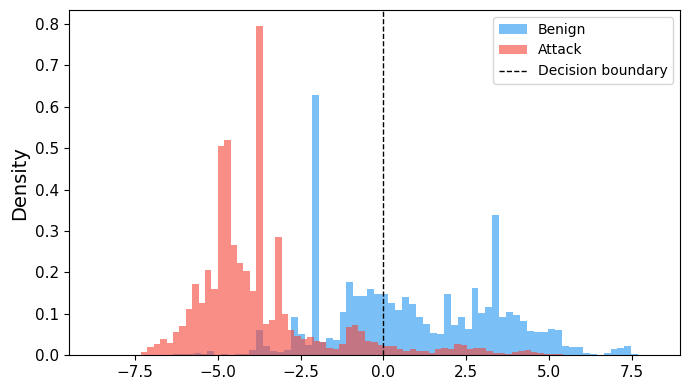

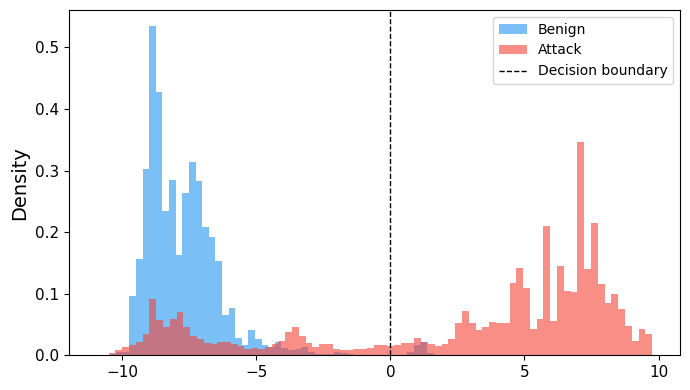


\begin{figure}[htbp]
    \centering
    \begin{subfigure}[b]{0.48\textwidth}
        \centering
        \includegraphics[width=\textwidth]{logit_separation_CICIDS2018_UNSW_NB15_before.pdf}
        \caption{Before CTTA}
        \label{fig:logit_separation_CICIDS2018_UNSW_NB15_before}
    \end{subfigure}
    \hfill
    \begin{subfigure}[b]{0.48\textwidth}
        \centering
        \includegraphics[width=\textwidth]{logit_separation_CICIDS2018_UNSW_NB15_after.pdf}
        \caption{After CTTA}
        \label{fig:logit_separation_CICIDS2018_UNSW_NB15_after}
    \end{subfigure}
    \caption{KAN — Logit Separation (CICIDS2018 $\rightarrow$ UNSW-NB15)}
    \label{fig:logit_separation_CICIDS2018_UNSW_NB15}
\end{figure}



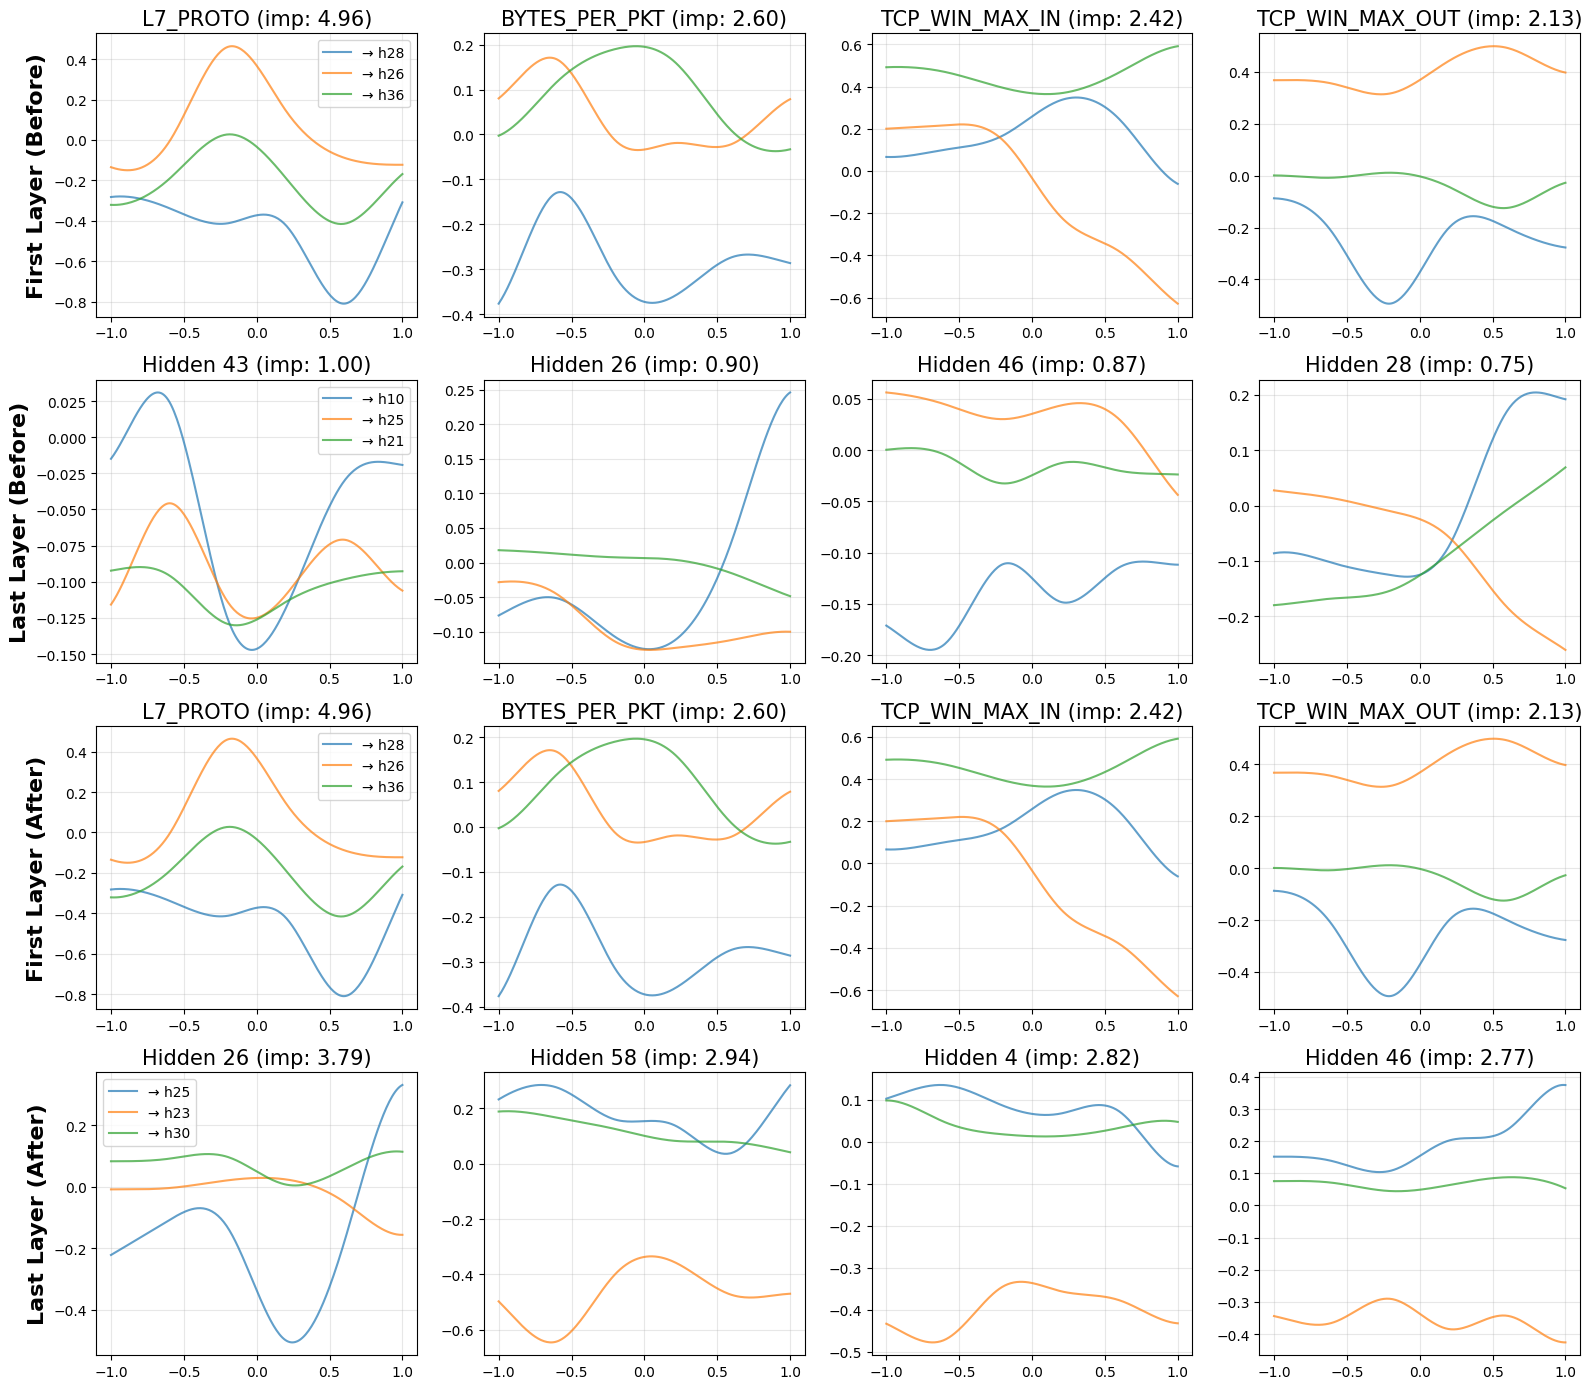


\begin{figure}[htbp]
    \centering
    \includegraphics[width=\textwidth]{spline_activations_CICIDS2018_UNSW_NB15.pdf}
    \caption{KAN Spline Activations — Before vs After CTTA (CICIDS2018 $\rightarrow$ UNSW-NB15)}
    \label{fig:spline_activations_CICIDS2018_UNSW_NB15}
\end{figure}



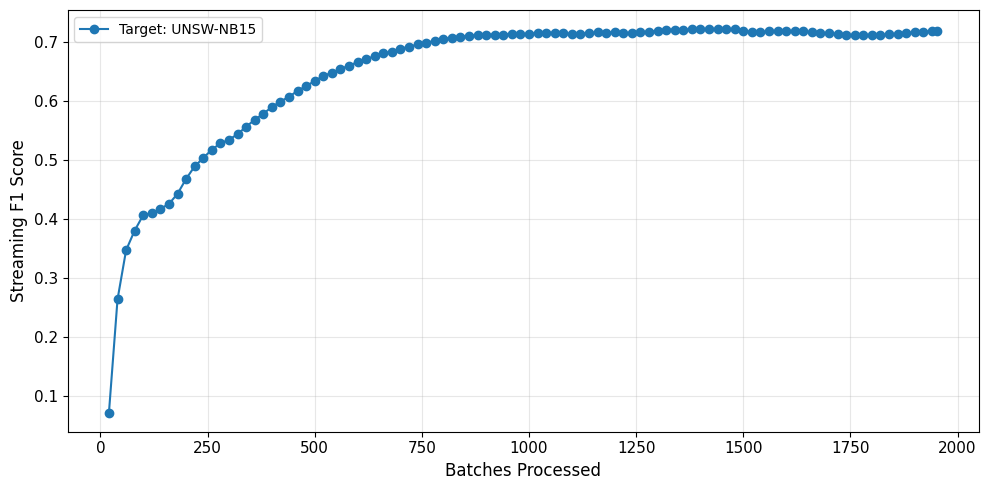


\begin{figure}[htbp]
    \centering
    \includegraphics[width=\textwidth]{adaptation_trajectory_CICIDS2018.pdf}
    \caption{CTTA Adaptation Trajectory (Source: CICIDS2018)}
    \label{fig:adaptation_trajectory_CICIDS2018}
\end{figure}



In [113]:
architectures = ['kan']  # Only KAN is needed for visualizations
datasets = {
    'CICIDS2018': 'seyhed/nf-cicids2018-v3',
    'ToN-IoT': 'seyhed/nf-ton-iot-v3',
    'UNSW-NB15': 'seyhed/nf-unsw-nb15-v3'
}

for arch in architectures:
    for src_name, src_path in datasets.items():
        if src_name != 'CICIDS2018':
            continue  # Temporarily only run for UNSW-NB15 source

        seed_everything(SEED)

        print('=' * 80)
        print(f'VISUALIZATION PATH | Arch: {arch.upper()} | Source: {src_name}')
        print('=' * 80)

        # 1. Load Source
        X_src, y_src, feature_names = load_dataset(src_path, sample_n=SAMPLE_N)
        input_dim = X_src.shape[1]
        loader_src_train, loader_src_test, source_scaler = make_source_loaders(X_src, y_src)
        del X_src, y_src; gc.collect()

        # 2. Pre-train Model
        model = run_phase1_pretraining(arch, src_name, input_dim,
                                       loader_src_train, device,
                                       PRETRAIN_EPOCHS, LATENT_DIM)

        model_state = {k: v.clone() for k, v in model.state_dict().items()}

        kan_ret = None
        if arch == 'kan':
            model.load_state_dict(model_state)
            params_to_protect = get_spline_only_params(model) if SPLINE_TRUE \
                                else get_trainable_params(model)
            kan_ret = KAN_Retention(model, loader_src_test, device, params_to_protect)

        # 3. Adaptation & Visualizations
        targets = {k: v for k, v in datasets.items() if k != src_name}
        trajectories = {}

        for tgt_name, tgt_path in targets.items():
            if tgt_name != 'UNSW-NB15':
                continue  # Temporarily only run for UNSW-NB15 target


            X_tgt, y_tgt, _ = load_dataset(tgt_path, sample_n=SAMPLE_N,
                                           align_to=list(feature_names))
            pool_tgt_src_sc, stream_tgt_src_sc = make_target_loaders(
                X_tgt, y_tgt, external_scaler=source_scaler)
            del X_tgt, y_tgt; gc.collect()

            model.load_state_dict(model_state)
            preds_m, labels_m, traj_m = run_ctta(
                model, stream_tgt_src_sc, pool_tgt_src_sc, device,
                spline_only=SPLINE_TRUE,
                ewc=kan_ret, ewc_lambda=EWC_LAMBDA,
            )

            trajectories[tgt_name] = traj_m

            if arch == 'kan':
                run_all_visualizations(model_state, model, stream_tgt_src_sc,
                                       pool_tgt_src_sc, src_name, tgt_name,
                                       device, feature_names, trajectories)


--- Manual Visualization Rerun: UNSW-NB15 -> UNSW-NB15 ---

--- Running KAN Visualizations: UNSW-NB15 -> UNSW-NB15 ---


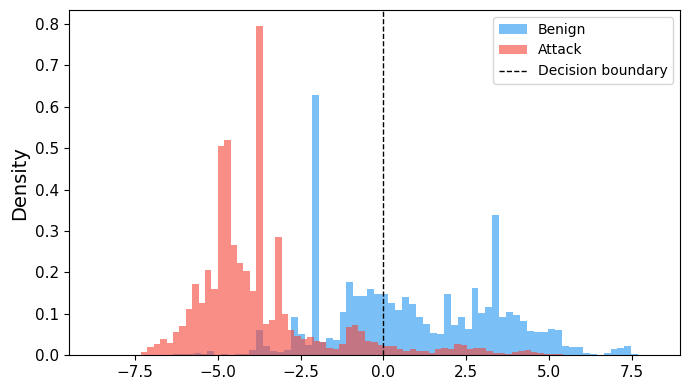

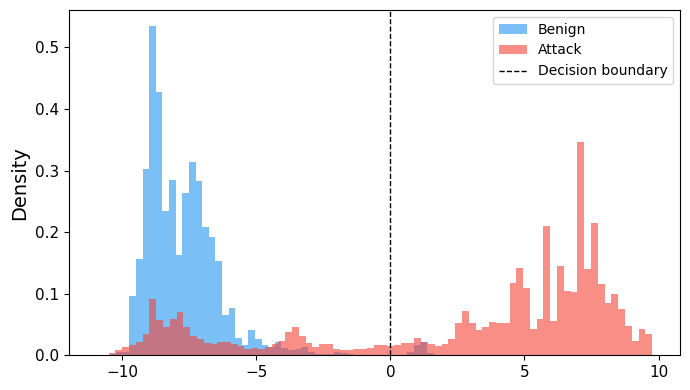


\begin{figure}[htbp]
    \centering
    \begin{subfigure}[b]{0.48\textwidth}
        \centering
        \includegraphics[width=\textwidth]{logit_separation_UNSW_NB15_UNSW_NB15_before.pdf}
        \caption{Before CTTA}
        \label{fig:logit_separation_UNSW_NB15_UNSW_NB15_before}
    \end{subfigure}
    \hfill
    \begin{subfigure}[b]{0.48\textwidth}
        \centering
        \includegraphics[width=\textwidth]{logit_separation_UNSW_NB15_UNSW_NB15_after.pdf}
        \caption{After CTTA}
        \label{fig:logit_separation_UNSW_NB15_UNSW_NB15_after}
    \end{subfigure}
    \caption{KAN — Logit Separation (UNSW-NB15 $\rightarrow$ UNSW-NB15)}
    \label{fig:logit_separation_UNSW_NB15_UNSW_NB15}
\end{figure}



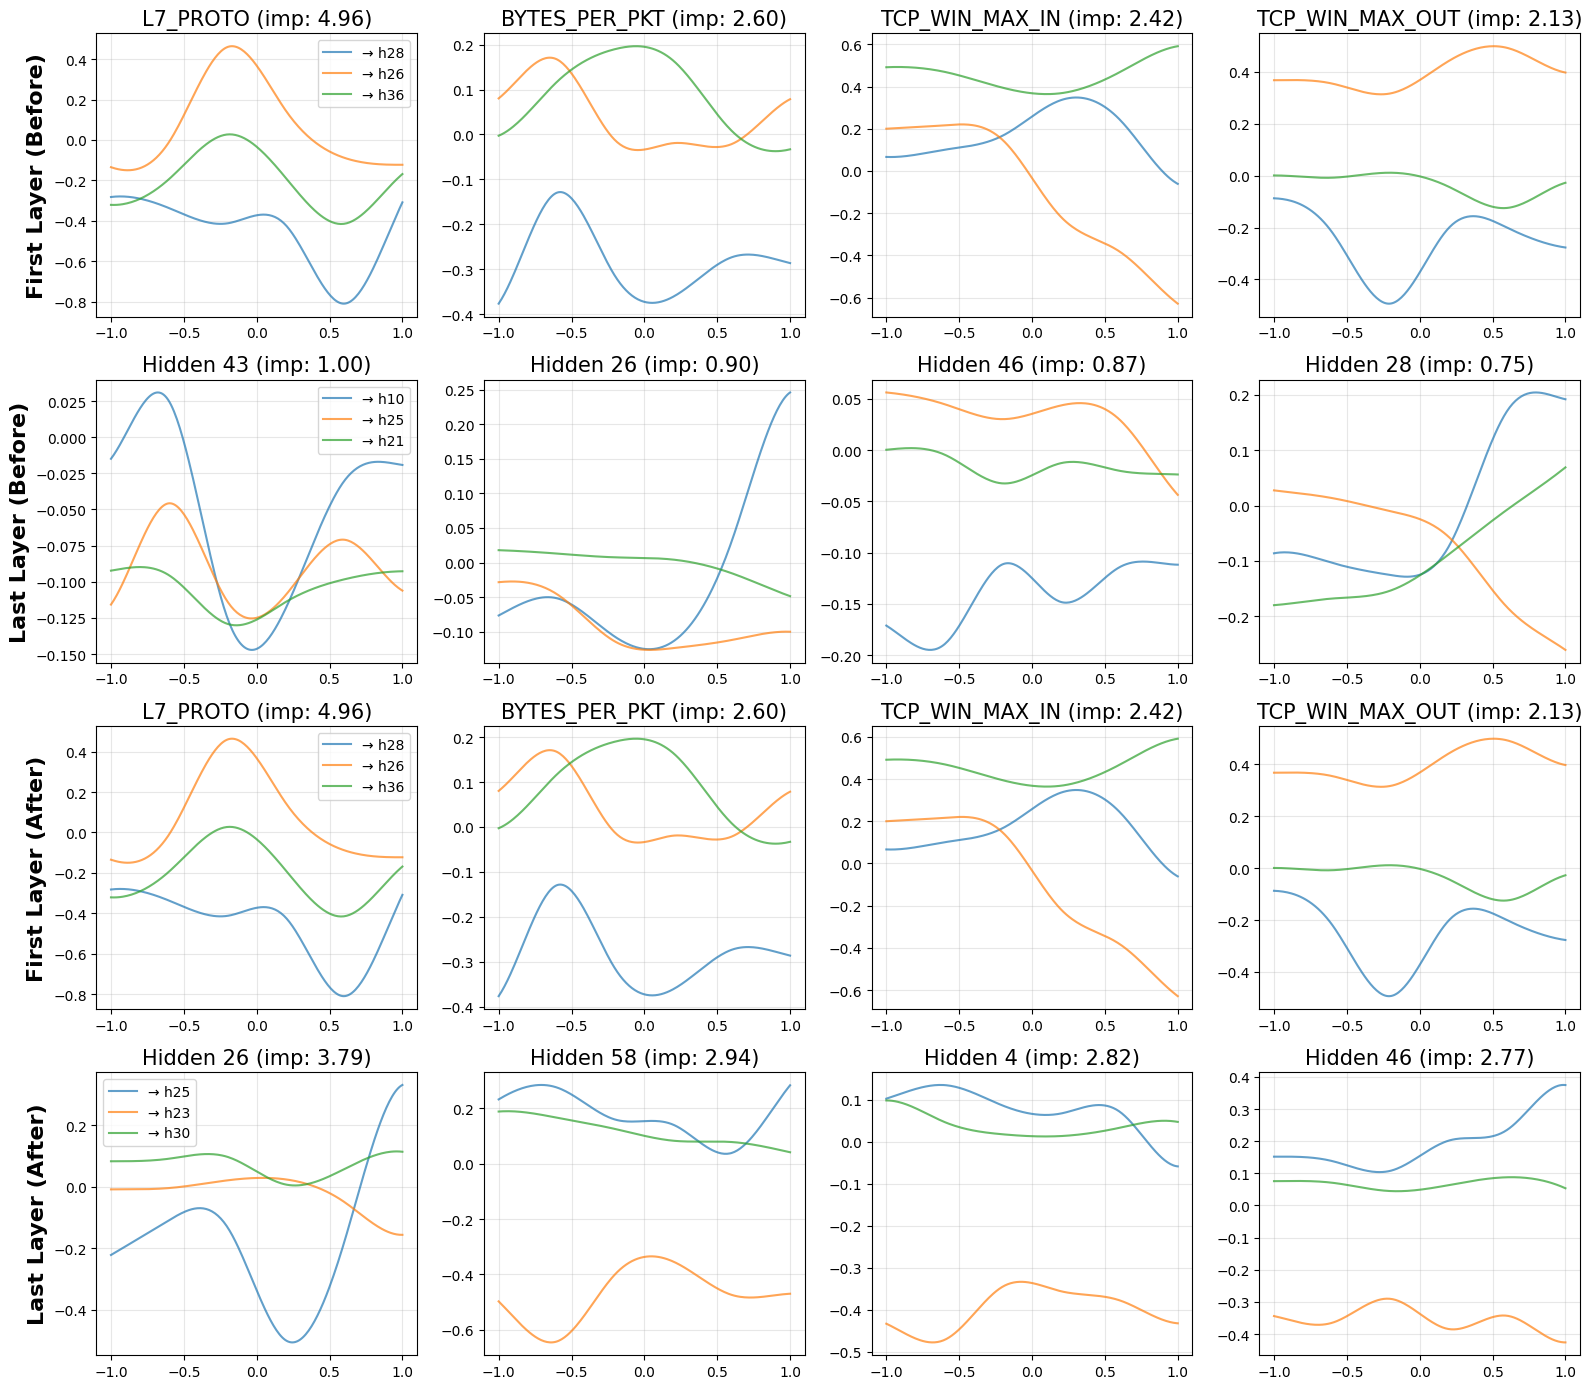


\begin{figure}[htbp]
    \centering
    \includegraphics[width=\textwidth]{spline_activations_UNSW_NB15_UNSW_NB15.pdf}
    \caption{KAN Spline Activations — Before vs After CTTA (UNSW-NB15 $\rightarrow$ UNSW-NB15)}
    \label{fig:spline_activations_UNSW_NB15_UNSW_NB15}
\end{figure}



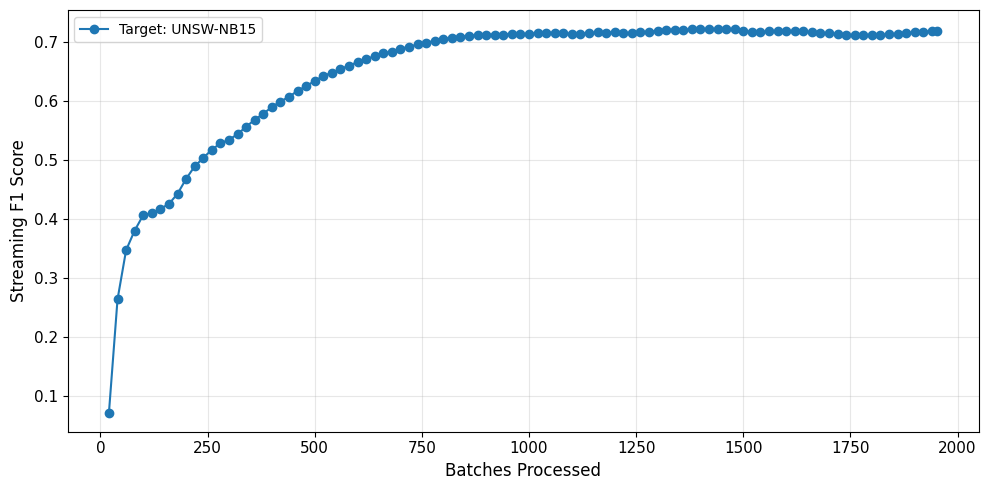


\begin{figure}[htbp]
    \centering
    \includegraphics[width=\textwidth]{adaptation_trajectory_UNSW_NB15.pdf}
    \caption{CTTA Adaptation Trajectory (Source: UNSW-NB15)}
    \label{fig:adaptation_trajectory_UNSW_NB15}
\end{figure}



In [114]:
# Manually re-run visualization using the persisted model and data
try:
    if arch == 'kan':
        print(f"--- Manual Visualization Rerun: {src_name} -> {tgt_name} ---")
        run_all_visualizations(model_state, model, stream_tgt_src_sc,
                               pool_tgt_src_sc, src_name, tgt_name,
                               device, feature_names,trajectories)
except NameError as e:
    print("Variables not found. Please run the grid experiment cell first.")


In [115]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
